# F06: Diurnal cycles

# Preamble

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import sys
import metpy
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import metpy.calc as mpcalc
import pandas as pd
from netCDF4 import Dataset
import pyproj
import os
import glob
from datetime import datetime
import seaborn as sns
import netCDF4
from netCDF4 import Dataset
from metpy.units import units
import dask
import xarray as xr
from shapely import Polygon
import regionmask
import geopandas as gpd
import logging
import dask
from dask.distributed import Client
from dask import delayed
import functools
import zipfile
import tempfile
import wradlib as wrl
sys.path.append(os.path.join(r"/home/563/ac9768/GBR/scripts/Paper_figures")) 
# from define_wind_regimes import wind_times

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
barra_towns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_townsville.nc", engine="h5netcdf",chunks="auto")
barra_cairns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_cairns.nc", engine="h5netcdf",chunks="auto")
barra_willis = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_willis_island.nc", engine="h5netcdf",chunks="auto")

In [4]:
from dask_setup import setup_dask_client 
from dask_setup import recommend_chunks
client, cluster, dask_tmp = setup_dask_client(mode="interactive", workload_type="cpu") # 'io','mixed'(io and cpu=computation), 'auto' (inferred from ds)

INFO     [client] Interactive cluster mode — using already-allocated nodes
INFO     [multinode] Interactive cluster: single node, using LocalCluster (node=gadi-cpu-bdw-0142.gadi.nci.org.au)
INFO     [client] Starting Dask client setup (workload_type=cpu | environment=jupyter)
INFO     [resources] Resources detected via PBS (total_cores=28 | total_mem_gib=252.0)


INFO     [client] Temp/spill dir: /jobfs/172057271.gadi-pbs/dask-1844723
INFO     [client] Workers: 28 | threads/worker: 1 | processes: True
INFO     [client] Mem: total ~252.0 GiB | usable ~202.0 GiB | per-worker ~7.2 GiB
INFO     [client] Compression: spill=auto | comm=False
INFO     [client] Dask client ready


[setup_dask_client] Configuration summary
temp/spill dir: /jobfs/172057271.gadi-pbs/dask-1844723
Workers: 28 | threads/worker: 1 | processes: True
Memory: total ~252.0 GiB | usable ~202.0 GiB | per-worker ~7.2 GiB
Compression: spill=auto | comm=False


# calculate BT diurnal cycles

In [5]:
# read in satellite files
def him8_files(directory):
    file_paths = []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.endswith("_ch13BT_regridded_2kmres.nc"):  
                file_paths.append(os.path.join(root, file))
    return file_paths
directory = "/g/data/q90/ac9768/GBR/him8"
files = him8_files(directory)

In [6]:
def utc_to_lst_shift(ds, longitude_center: float):
    """
    Shift xarray data from UTC to Local Solar Time by offsetting the 
    time coordinate. Adds the LST offset to time labels directly —
    does NOT roll/wrap data values.

    Args:
        ds:               xarray Dataset or DataArray with a 'time' dimension.
        longitude_center: Representative longitude of the region (decimal degrees).

    Returns:
        Dataset/DataArray with time coordinate relabelled to LST.
    """
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    ds_lst = ds.assign_coords(time=ds.time + offset)
    return ds_lst

In [7]:
# define 12 LST wind regime definition
def wind_times(barra_regime_ds: xr.Dataset, longitude_center: float):
    """
    Classify wind direction at LST solar noon (hour=12), then assign
    all hours of that day to the same wind regime.

    Args:
        barra_regime_ds:  xarray Dataset with 'wind_dir' and 'time' dimension.
        longitude_center: Representative longitude for LST conversion.

    Returns:
        ne, se, sw, nw: arrays of datetime64 timestamps (all hours) 
                        belonging to each wind regime day.
    """
    # 1. Shift full dataset to LST
    ds_lst = utc_to_lst_shift(barra_regime_ds, longitude_center)

    # 2. Extract wind_dir and compute (needed for boolean indexing)
    winds = ds_lst.wind_dir.compute()

    # 3. Select only solar noon (LST hour=12) for regime classification
    winds_noon = winds.sel(time=winds.time.dt.hour == 12)

    # 4. Classify noon wind direction → get dates (not full timestamps)
    ne_dates = winds_noon.time.values[(winds_noon.values >= 0)   & (winds_noon.values <= 90)]
    se_dates = winds_noon.time.values[(winds_noon.values > 90)   & (winds_noon.values <= 180)]
    sw_dates = winds_noon.time.values[(winds_noon.values > 180)  & (winds_noon.values <= 270)]
    nw_dates = winds_noon.time.values[(winds_noon.values > 270)  & (winds_noon.values <= 360)]

    # 5. Convert noon timestamps → date-only for day matching
    def noon_to_all_hours(regime_noon_times):
        """Given noon timestamps, return all LST timestamps on those days."""
        regime_dates = set(
            pd.Timestamp(t).date() for t in regime_noon_times
        )
        all_times = pd.DatetimeIndex(winds.time.values)
        mask = all_times.normalize().map(lambda d: d.date() in regime_dates)
        return winds.time.values[mask]

    ne_lst = noon_to_all_hours(ne_dates)
    se_lst = noon_to_all_hours(se_dates)
    sw_lst = noon_to_all_hours(sw_dates)
    nw_lst = noon_to_all_hours(nw_dates)

    # 6. Convert LST timestamps back to UTC by subtracting the offset
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    # ds_lst = ds.assign_coords(time=ds.time + offset)

    
    # offset_hours = round(longitude_center * 4 / 60)
    # offset = np.timedelta64(offset_hours, 'h')

    ne = ne_lst - offset
    se = se_lst - offset
    sw = sw_lst - offset
    nw = nw_lst - offset

    return ne, se, sw, nw


# --- Usage ---
lon_towns  = (145.12054 + 147.9812)  / 2  # ≈ 146.55°E
lon_cairns = (144.27374 + 147.09222) / 2  # ≈ 145.68°E
lon_willis = (148.55927 + 151.36993) / 2

ne_towns,  se_towns,  sw_towns,  nw_towns  = wind_times(barra_towns,  lon_towns)
ne_cairns, se_cairns, sw_cairns, nw_cairns = wind_times(barra_cairns, lon_cairns)
ne_willis, se_willis, sw_willis, nw_willis = wind_times(barra_willis, lon_willis)

In [8]:
def proj_mask_ds(mask_ds_path: str,radar_gndrefl_nc_filepath: str,):
    with xr.open_dataset(radar_gndrefl_nc_filepath) as ref:
        x_grid, y_grid = np.meshgrid(ref.x.data, ref.y.data)
        proj = pyproj.Proj(
            proj='aea',
            lat_1=ref.proj.standard_parallel[0],
            lat_2=ref.proj.standard_parallel[1],
            lat_0=ref.proj.latitude_of_projection_origin,
            lon_0=ref.proj.longitude_of_central_meridian,
            x_0=0, y_0=0
        )
        lon_grid, lat_grid = proj(x_grid * 1000, y_grid * 1000, inverse=True)

        lat_da   = xr.DataArray(lat_grid, dims=['y', 'x'])
        lon_da   = xr.DataArray(lon_grid, dims=['y', 'x'])

        mask_ds = xr.open_dataset(mask_ds_path)
        mask_ds = mask_ds.assign(lat=lat_da, lon=lon_da)
    return mask_ds

In [9]:
regimes = ['ne','se','sw','nw']

sites= {
    'towns':{
        'lat_slice':slice(-20.768799,-18.065369),
        'lon_slice':slice(145.10834,147.99347),
        'land_mask':   proj_mask_ds('/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/radar_masks/bbANDland_mask_towns.nc',
                                        str(glob.glob(f'/scratch/v46/ac9768/radar_grndref/radar_73_*/73_*.gndrefl.nc')[0])),
        'ocean_mask':  proj_mask_ds('/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/radar_masks/bbANDocean_mask_towns.nc',
                                        str(glob.glob(f'/scratch/v46/ac9768/radar_grndref/radar_73_*/73_*.gndrefl.nc')[0])),
        'ne':ne_towns,
        'se':se_towns,
        'sw':sw_towns,
        'nw':nw_towns,
        'clim':barra_towns.time.values,
    },
    'cairns':{
        'lat_slice':slice(-18.165955,-15.463379),
        'lon_slice':slice(144.26343,147.1026),
        'land_mask': proj_mask_ds('/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/radar_masks/bbANDland_mask_cairns.nc',
                                        str(glob.glob(f'/scratch/v46/ac9768/radar_grndref/radar_19_*/19_*.gndrefl.nc')[0])),
        'ocean_mask': proj_mask_ds('/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/radar_masks/bbANDocean_mask_cairns.nc',
                                        str(glob.glob(f'/scratch/v46/ac9768/radar_grndref/radar_19_*/19_*.gndrefl.nc')[0])),
        'ne':ne_cairns,
        'se':se_cairns,
        'sw':sw_cairns,
        'nw':nw_cairns,
        'clim':barra_cairns.time.values,
    },
    'willis':{
        'lat_slice':slice(-17.636353,-14.93396),
        'lon_slice':slice(148.54926,151.37994),
        'land_mask':None,
        'ocean_mask':None,
        'ne':ne_willis,
        'se':se_willis,
        'sw':sw_willis,
        'nw':nw_willis,
        'clim':barra_willis.time.values,
    },
}

FileNotFoundError: [Errno 2] No such file or directory: '/home/563/ac9768/GBR/scripts/Paper_figures/radar_masks/bbANDland_mask_towns.nc'

In [ ]:
def open_him8(files, sites, regimes):
    """
    Open Himawari-8 multi-file dataset and select data by site and regime.
    If radar masks exist (with lat/lon as variables), selects satellite pixels
    that fall within the True mask region for each site.

    Parameters
    ----------
    files : str or list
        Glob pattern or list of files to open with open_mfdataset.
    sites : dict
        Site definitions with:
          - 'lat_slice', 'lon_slice'   : spatial bounds for sat subset
          - 'land_mask'                : output of proj_mask_ds() or None
          - 'ocean_mask'               : output of proj_mask_ds() or None
          - '<regime>'                 : xr.DataArray of datetimes per regime
    regimes : list of str
        Regime labels (e.g. ['ne','se','sw','nw']).

    Returns
    -------
    dict : {
        site_name: {
            regime: {
                'sat'         : xr.Dataset  (lat/lon grid, time-selected),
                'land_mask'   : xr.Dataset  (projected mask or None),
                'ocean_mask'  : xr.Dataset  (projected mask or None),
                'sat_land'    : xr.Dataset  (sat pixels within land mask, or None),
                'sat_ocean'   : xr.Dataset  (sat pixels within ocean mask, or None),
            }
        }
    }
    """
    ds = xr.open_mfdataset(files, combine='by_coords')
    results = {}

    for site_name, site_cfg in sites.items():
        print(f"\nProcessing site: {site_name}")
        results[site_name] = {}

        lat_slice  = site_cfg['lat_slice']
        lon_slice  = site_cfg['lon_slice']
        land_mask  = site_cfg['land_mask']    # xr.Dataset with lat/lon vars, or None
        ocean_mask = site_cfg['ocean_mask']   # xr.Dataset with lat/lon vars, or None
        masks_exist = (land_mask is not None) or (ocean_mask is not None)

        # ── Sat data ──────────────────────────────────────────────────────────────────
        ds_site = ds.sel(
            lat=lat_slice,
            lon=lon_slice,
        )
        sat_lat = ds_site.lat.values   # 1-D (n_lat,)
        sat_lon = ds_site.lon.values   # 1-D (n_lon,)

        def mask_sat(site_cfg,mask,sat_lat,sat_lon):
            mask_ds = mask
            bool_field = mask_ds['__xarray_dataarray_variable__'] == True
            
            # Assign the 2D lat/lon variables as coordinates on the mask
            bool_field = bool_field.assign_coords(
                lat=mask_ds['lat'],   # (y, x)
                lon=mask_ds['lon'],   # (y, x)
            )
            mask_lats = mask_ds['lat'].values   # (y, x)
            mask_lons = mask_ds['lon'].values   # (y, x)
            bool_vals = (mask_ds['__xarray_dataarray_variable__'] == True).values  # (y, x)

            # Only use lat/lon where mask is True
            true_lats = mask_lats[bool_vals]
            true_lons = mask_lons[bool_vals]

            # Snap to nearest sat grid index
            lat_idx = np.argmin(np.abs(sat_lat[:, None] - true_lats[None, :]), axis=0)
            lon_idx = np.argmin(np.abs(sat_lon[:, None] - true_lons[None, :]), axis=0)

            sat_bool = np.zeros((len(sat_lat), len(sat_lon)), dtype=bool)
            sat_bool[lat_idx, lon_idx] = True
            
            sat_bool_da = xr.DataArray(
                sat_bool,
                dims=['lat', 'lon'],
                coords={'lat': sat_lat, 'lon': sat_lon},
            )
            return sat_bool_da

        # use function to create satellite masks
        land_sat_mask  = mask_sat(site_cfg,land_mask,sat_lat,sat_lon)  if land_mask  is not None else None
        ocean_sat_mask = mask_sat(site_cfg,ocean_mask,sat_lat,sat_lon) if ocean_mask is not None else None

        # ── Per-regime selection ───────────────────────────────────────────────
        for regime in regimes:
            if regime not in site_cfg:
                print(f"  Skipping {site_name}/{regime}: no time DataArray defined.")
                continue

            times = site_cfg[regime]   # xr.DataArray of datetimes

            valid_times = times[
                np.isin(times, ds_site.time.values)
            ]

            if len(valid_times) == 0:
                print(f"  Warning: no matching times for {site_name}/{regime}")
                results[site_name][regime] = {
                    'sat': None, 'land_mask': land_mask, 'ocean_mask': ocean_mask,
                    'sat_land': None, 'sat_ocean': None,
                }
                continue

            ds_regime = ds_site.sel(time=valid_times)

            # ── Apply boolean sat mask for land / ocean ────────────────────────
            def apply_sat_mask(ds_r, sat_mask):
                ds_mean = ds_r.ch13BT.where(sat_mask).groupby('time.hour').mean(['time','lat','lon'])
                return ds_mean

            sat_ocean  = apply_sat_mask(ds_regime, land_sat_mask)  if land_sat_mask  is not None else None
            sat_land = apply_sat_mask(ds_regime, ocean_sat_mask) if ocean_sat_mask is not None else None
            
            if site_name=='willis':
                sat_ocean = ds_regime.ch13BT.groupby('time.hour').mean(['time','lat','lon'])
                
            results[site_name][regime] = {
                'sat':        ds_regime,   # full spatial subset, all times
                'land_mask':  land_sat_mask,   # projected mask dataset
                'ocean_mask': ocean_sat_mask,
                'sat_land':   sat_land,    # sat pixels inside land mask
                'sat_ocean':  sat_ocean,   # sat pixels inside ocean mask
            }
            print(f"  ✓ {site_name}/{regime}: {len(valid_times)} timesteps")

    return results

In [ ]:
results = open_him8(files, sites, regimes)


In [ ]:
def utc_hour_to_lst(da, longitude_center: float):
    offset_hours = round(longitude_center * 4 / 60)
    # print(offset_hours)
    da_lst = da.roll(hour=offset_hours)  # negative to shift forward in LST
    da_lst = da_lst.assign_coords(hour=(da_lst.hour % 24))
    da_lst = da_lst.sortby('hour')
    return da_lst
    
lon_centers = {
    'towns': 146.5509,
    'cairns':  145.683,
    'willis': 149.9646,
}

In [ ]:
# save files
save_dir = '/home/563/ac9768/GBR/scripts/Paper_figures/Fig6_12LST_windregime_def/archive'
os.makedirs(save_dir, exist_ok=True)

for site_name, lons in lon_centers.items():
    lon = lons

    for regime in regimes:
        r = results[site_name][regime]

        if r['sat_ocean'] is not None:
            lst_ocean = utc_hour_to_lst(r['sat_ocean'], lon).compute()

            # Reset points index so it saves cleanly (no MultiIndex)
            if 'points' in lst_ocean.dims:
                lst_ocean = lst_ocean.reset_index('points', drop=True)

            lst_ocean.to_netcdf(
                os.path.join(save_dir, f'him8_diurnal_{site_name}_{regime}_ocean.nc')
            )
            print(f"  Saved: {site_name}/{regime} ocean")

        if r['sat_land'] is not None:
            lst_land = utc_hour_to_lst(r['sat_land'], lon).compute()

            if 'points' in lst_land.dims:
                lst_land = lst_land.reset_index('points', drop=True)

            lst_land.to_netcdf(
                os.path.join(save_dir, f'him8_diurnal_{site_name}_{regime}_land.nc')
            )
            print(f"  Saved: {site_name}/{regime} land")

# Plot (all data in same base path)

In [5]:
# create plotting dictionaries with clim ---------------------------------
regimes = ['nw', 'ne', 'sw', 'se','clim']
colors  = {'nw': '#FE6100', 'ne': '#FFB000', 'sw': '#785EF0', 'se': '#648FFF','clim':'black'}
base    = '/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/Fig6_12LST_windregime_def'
base_clim    = '/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/Fig11_diurnal_clim'

Tocean, Tland, Tocean_freq, Tland_freq = {}, {}, {}, {}
ocean, land, ocean_freq, land_freq = {}, {}, {}, {}
willis_ocean, willis_ocean_freq = {}, {}

for regime in regimes:
    if regime=='clim':
        Tocean[regime]      = xr.open_zarr(f'{base_clim}/towns_{regime}_ocean_mean_rainrate.zarr').rainrate
        Tland[regime]       = xr.open_zarr(f'{base_clim}/towns_{regime}_land_mean_rainrate.zarr').rainrate
        Tocean_freq[regime] = xr.open_zarr(f'{base_clim}/towns_{regime}_ocean_freq.zarr').freq
        Tland_freq[regime]  = xr.open_zarr(f'{base_clim}/towns_{regime}_land_freq.zarr').freq
        ocean[regime]      = xr.open_zarr(f'{base_clim}/cairns_{regime}_ocean_mean_rainrate.zarr').rainrate
        land[regime]       = xr.open_zarr(f'{base_clim}/cairns_{regime}_land_mean_rainrate.zarr').rainrate
        ocean_freq[regime] = xr.open_zarr(f'{base_clim}/cairns_{regime}_ocean_freq.zarr').freq
        land_freq[regime]  = xr.open_zarr(f'{base_clim}/cairns_{regime}_land_freq.zarr').freq
        willis_ocean[regime]      = xr.open_zarr(f'{base_clim}/willis_{regime}_ocean_mean_rainrate.zarr').rainrate
        willis_ocean_freq[regime] = xr.open_zarr(f'{base_clim}/willis_{regime}_ocean_freq.zarr').freq
    else:
        Tocean[regime]      = xr.open_zarr(f'{base}/towns_{regime}_ocean_mean_rainrate.zarr').rainrate
        Tland[regime]       = xr.open_zarr(f'{base}/towns_{regime}_land_mean_rainrate.zarr').rainrate
        Tocean_freq[regime] = xr.open_zarr(f'{base}/towns_{regime}_ocean_freq.zarr').freq
        Tland_freq[regime]  = xr.open_zarr(f'{base}/towns_{regime}_land_freq.zarr').freq
        ocean[regime]      = xr.open_zarr(f'{base}/cairns_{regime}_ocean_mean_rainrate.zarr').rainrate
        land[regime]       = xr.open_zarr(f'{base}/cairns_{regime}_land_mean_rainrate.zarr').rainrate
        ocean_freq[regime] = xr.open_zarr(f'{base}/cairns_{regime}_ocean_freq.zarr').freq
        land_freq[regime]  = xr.open_zarr(f'{base}/cairns_{regime}_land_freq.zarr').freq
        willis_ocean[regime]      = xr.open_zarr(f'{base}/willis_{regime}_ocean_mean_rainrate.zarr').rainrate
        willis_ocean_freq[regime] = xr.open_zarr(f'{base}/willis_{regime}_ocean_freq.zarr').freq
bt = {
    'towns_land': {},
    'towns_ocean': {},
    'cairns_land':   {},
    'cairns_ocean':  {},
    'willis_ocean':  {},
}
bt_dir = '/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/Fig6_12LST_windregime_def/archive'

for regime in regimes:
    bt['towns_land'][regime]  = xr.open_dataset(f'{bt_dir}/him8_diurnal_towns_{regime}_land.nc').ch13BT
    bt['towns_ocean'][regime] = xr.open_dataset(f'{bt_dir}/him8_diurnal_towns_{regime}_ocean.nc').ch13BT
    bt['cairns_land'][regime]  = xr.open_dataset(f'{bt_dir}/him8_diurnal_cairns_{regime}_land.nc').ch13BT
    bt['cairns_ocean'][regime] = xr.open_dataset(f'{bt_dir}/him8_diurnal_cairns_{regime}_ocean.nc').ch13BT
    bt['willis_ocean'][regime] = xr.open_dataset(f'{bt_dir}/him8_diurnal_willis_{regime}_ocean.nc').ch13BT


def utc_hour_to_lst(da, longitude_center: float):
    offset_hours = round(longitude_center * 4 / 60)
    # print(offset_hours)
    da_lst = da.roll(hour=offset_hours)  # negative to shift forward in LST
    da_lst = da_lst.assign_coords(hour=(da_lst.hour % 24))
    da_lst = da_lst.sortby('hour')
    return da_lst

lon_centers = {
    'towns': 146.5509,
    'cairns':  145.683,
    'willis': 149.9646,
}
lon_t = lon_centers['towns']
lon_c = lon_centers['cairns']
lon_w = lon_centers['willis']

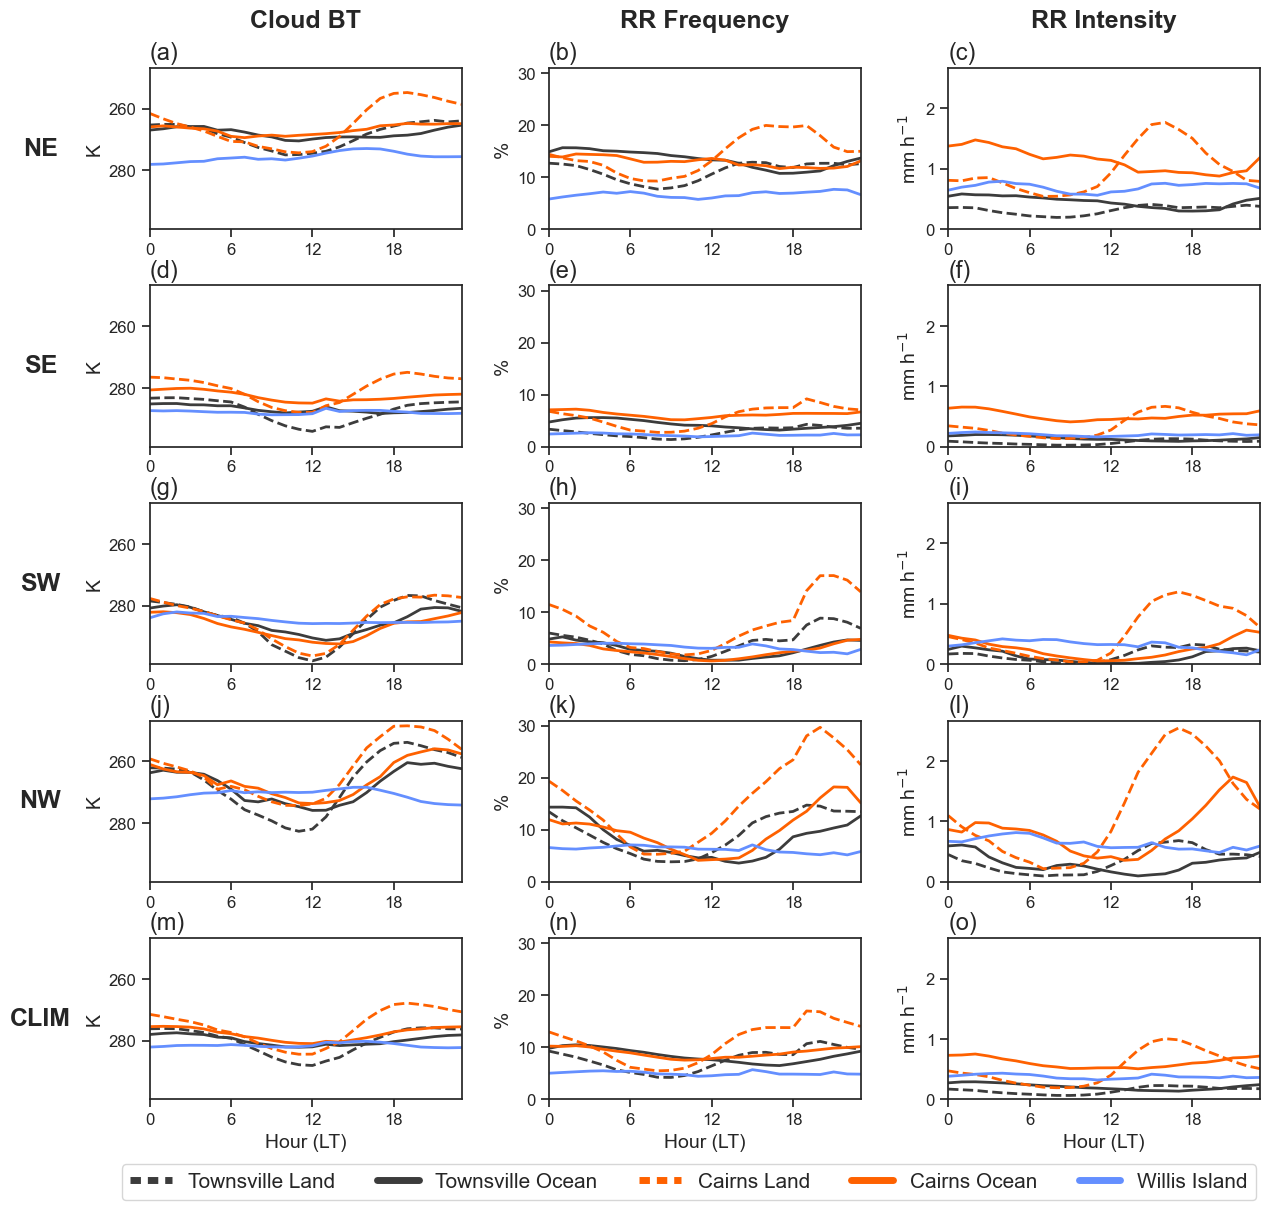

In [10]:
# plot regime vs data (all sites within the same panels) with CLIM ---------------
fig, axes = plt.subplots(5, 3, figsize=(12, 11))
fig.tight_layout()
sns.set_theme(style="ticks")
fig.subplots_adjust(
    hspace=0.35,  # vertical spacing between rows
    wspace=0.28   # horizontal spacing between columns
)
hours = np.arange(0, 24, 1)

titles        = ['Cloud BT', 'RR Frequency', 'RR Intensity']
regime_labels = ['NE', 'SE', 'SW', 'NW','CLIM']
regimes       = ['ne', 'se', 'sw', 'nw','clim']

# Okabe-Ito colorblind-friendly palette
site_colors = {
    'towns':  '#3C3C3C',#FFB000',
    'cairns': '#FE6100',
    'willis': '#648FFF',
}

# (label, bt_key, freq_dict, mean_dict, lon, linestyle)
series_cfg = [
    ('Townsville Land',  'towns_land',   Tland_freq,        Tland,        lon_t, '--', 'towns'),
    ('Townsville Ocean', 'towns_ocean',  Tocean_freq,       Tocean,       lon_t, '-',  'towns'),
    ('Cairns Land',      'cairns_land',  land_freq,         land,         lon_c, '--', 'cairns'),
    ('Cairns Ocean',     'cairns_ocean', ocean_freq,        ocean,        lon_c, '-',  'cairns'),
    ('Willis Island',    'willis_ocean', willis_ocean_freq, willis_ocean, lon_w, '-',  'willis'),
]

# ── Column titles ─────────────────────────────────────────────────────────────
for col, title in enumerate(titles):
    axes[0, col].set_title(title, fontsize=18,y=1.2, pad=15, weight='bold')

# ── Formatting ────────────────────────────────────────────────────────────────
for row in range(5):
    for col in range(3):
        letter = chr(97 + row * 3 + col)
        axes[row, col].set_title(f'({letter})', loc='left', fontsize=17)
        axes[row, col].set_xlim(0, 23)
        axes[row, col].set_xticks(np.arange(0, 24, 6))
        axes[row, col].tick_params(labelsize=12)
        if row == 4:
            axes[row, col].set_xlabel('Hour (LT)', fontsize=14)

    axes[row, 0].set_ylabel('K',            fontsize=14)
    axes[row, 1].set_ylabel('%',            fontsize=14)
    axes[row, 2].set_ylabel('mm h$^{-1}$', fontsize=14)

    # Regime label to the left of col-0
    axes[row, 0].text(
        x=-0.35, y=0.5, s=regime_labels[row],
        fontsize=18, ha='center', va='center',
        rotation=0, transform=axes[row, 0].transAxes,
        weight='bold',
    )

# ── Plot ──────────────────────────────────────────────────────────────────────
for row, regime in enumerate(regimes):
    for label, bt_key, freq_dict, mean_dict, lon, ls, site in series_cfg:
        col   = site_colors[site]
        bt_v  = bt[bt_key][regime].values
        frq_v = utc_hour_to_lst(freq_dict[regime], lon).values
        rr_v  = utc_hour_to_lst(mean_dict[regime], lon).values

        kw = dict(color=col, lw=2, linestyle=ls,
                  label=label if row == 0 else '_nolegend_')

        axes[row, 0].plot(hours, bt_v,  **kw)
        axes[row, 1].plot(hours, frq_v, **kw)
        axes[row, 2].plot(hours, rr_v,  **kw)

# ── Shared y-limits, BT inverted ─────────────────────────────────────────────
bt_min   = min(axes[r, 0].get_ylim()[0] for r in range(5))
bt_max   = max(axes[r, 0].get_ylim()[1] for r in range(5))
freq_max = max(axes[r, 1].get_ylim()[1] for r in range(5))
rr_max   = max(axes[r, 2].get_ylim()[1] for r in range(5))

for row in range(5):
    axes[row, 0].set_ylim(bt_max, bt_min)
    axes[row, 1].set_ylim(0, freq_max)
    axes[row, 2].set_ylim(0, rr_max)

# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color=site_colors['towns'],  lw=2.5, ls='--', label='Townsville Land'),
    Line2D([0], [0], color=site_colors['towns'],  lw=2.5, ls='-',  label='Townsville Ocean'),
    Line2D([0], [0], color=site_colors['cairns'], lw=2.5, ls='--', label='Cairns Land'),
    Line2D([0], [0], color=site_colors['cairns'], lw=2.5, ls='-',  label='Cairns Ocean'),
    Line2D([0], [0], color=site_colors['willis'], lw=2.5, ls='-',  label='Willis Island'),
]

leg=fig.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.06),
    fontsize=15,
    ncol=5,
    frameon=True,
)

for i, line in enumerate(leg.get_lines()):
    line.set_linewidth(5)
    if i == 0:
        line.set_dashes([1.5, 1])
    if i == 2:
        line.set_dashes([1.5, 1])

fig.savefig(
    '/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/f06vgray.png',
    bbox_inches='tight', dpi=300,
)
plt.show()

In [ ]:
# plot site vs data (all regimes within the same panels)
fig, axes = plt.subplots(5, 3, figsize=(10, 10))
fig.tight_layout()
sns.set_theme(style="ticks")

lon_t = lon_centers['towns']
lon_c = lon_centers['cairns']
lon_w = lon_centers['willis']
hours = np.arange(0, 24, 1)

titles   = ['Cloud BT', 'RR Frequency', 'RR Intensity']
ylabels  = ['Townsville\nLand', 'Cairns\nLand', 'Townsville\nOcean', 'Cairns\nOcean', 'Willis\nIsland']
regime_labels = ['NE','SE', 'SW', 'NW']
regimes = ['ne','se', 'sw', 'nw']
colors  = {'ne': '#FFB000', 'se': '#648FFF','sw': '#785EF0','nw': '#FE6100',}
# ── Column titles (bold, large) ───────────────────────────────────────────────
for col, title in enumerate(titles):
    axes[0, col].set_title(title, fontsize=18, pad=15, weight='bold')

# ── Row/col formatting ────────────────────────────────────────────────────────
for row in range(5):
    for col in range(3):
        letter = chr(97 + row * 3 + col)
        axes[row, col].set_title(f'({letter})', loc='left', fontsize=15)
        axes[row, col].set_xlim(0, 23)
        axes[row, col].set_xticks(np.arange(0, 24, 6))
        if row == 4:
            axes[row, col].set_xlabel('Hour (LT)', fontsize=15)
        axes[row, col].tick_params(labelsize=11)

    # y-axis limits and labels
    axes[row, 0].set_ylabel('K',            fontsize=15)
    axes[row, 1].set_ylabel('%',            fontsize=15)
    axes[row, 2].set_ylabel('mm h$^{-1}$', fontsize=15)

    # Bold site label to the left of col-0
    axes[row, 0].text(
        x=-0.5, y=0.35, s=ylabels[row],
        fontsize=15, ha='center', va='bottom',
        rotation=0, transform=axes[row, 0].transAxes,
        weight='bold',
    )

# ── Plot data ─────────────────────────────────────────────────────────────────
row_cfg = [
    # (row, bt_key,            freq_dict,    mean_dict,    lon  )
    (0,  'towns_land',   Tland_freq,        Tland,        lon_t),
    (1,  'cairns_land',  land_freq,         land,         lon_c),
    (2,  'towns_ocean',  Tocean_freq,       Tocean,       lon_t),
    (3,  'cairns_ocean', ocean_freq,        ocean,        lon_c),
    (4,  'willis_ocean', willis_ocean_freq, willis_ocean, lon_w),
]

for regime, color in colors.items():
    for row, bt_key, freq_dict, mean_dict, lon in row_cfg:
        bt_vals   = bt[bt_key][regime].values
        freq_vals = utc_hour_to_lst(freq_dict[regime], lon).values
        mean_vals = utc_hour_to_lst(mean_dict[regime], lon).values

        axes[row, 0].plot(hours, bt_vals,   color=color, lw=2.5, label=regime.upper())
        axes[row, 1].plot(hours, freq_vals, color=color, lw=2.5, label=regime.upper())
        axes[row, 2].plot(hours, mean_vals, color=color, lw=2.5, label=regime.upper())

# ── Shared y-limits per column, BT inverted ───────────────────────────────────
bt_min   = min(axes[r, 0].get_ylim()[0] for r in range(5))
bt_max   = max(axes[r, 0].get_ylim()[1] for r in range(5))
freq_max = max(axes[r, 1].get_ylim()[1] for r in range(5))
rr_max   = max(axes[r, 2].get_ylim()[1] for r in range(5))

for row in range(5):
    axes[row, 0].set_ylim(bt_max, bt_min)   # inverted
    axes[row, 1].set_ylim(0, freq_max)
    axes[row, 2].set_ylim(0, rr_max)

# ── Shared legend ─────────────────────────────────────────────────────────────
handles, _ = axes[0, 0].get_legend_handles_labels()
# One handle per regime (deduplicate)
handles = handles[:len(regimes)]
fig.legend(
    handles=handles,
    labels=regime_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.07),
    fontsize=15,
    ncol=len(regime_labels),
    frameon=True,
)

fig.savefig(
    '/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/f11_sites.png',
    bbox_inches='tight', dpi=300,
)
plt.show()